# 03 -  Desarrollo de Modelo Predictivo

## 1. Descripción General

En este notebook se desarrollará la fase de modelado del proyecto de predicción de precios de Airbnb. El objetivo principal de esta etapa es entrenar, evaluar y comparar distintos modelos de Machine Learning capaces de estimar el precio de una propiedad a partir de las variables seleccionadas durante los procesos de *Data Exploration* y *Feature Engineering*.

A diferencia de las etapas anteriores, donde el enfoque estuvo centrado en la comprensión de los datos, la creación de características y la selección de variables, en esta fase se trabajará sobre un dataset final (`df_model`) que ya ha sido preprocesado, transformado y validado. Esto permite concentrar el análisis exclusivamente en el desempeño de los modelos predictivos.

Para este proyecto se utilizarán tres enfoques de modelado:

- ***Linear Regression***: como modelo baseline de referencia debido a su simplicidad e interpretabilidad.
- ***Random Forest Regressor***: un modelo basado en ensambles de árboles capaz de capturar relaciones no lineales entre las variables.
- ***XGBoost Regressor***: uno de los algoritmos más utilizados en problemas de datos tabulares por su capacidad predictiva y robustez.

El proceso de modelado abarca los pasos necesarios para entrenar, evaluar y seleccionar el mejor modelo:

- División de los datos en conjuntos de entrenamiento, validación y prueba.
- Entrenamiento de los modelos candidatos con hiperparámetros iniciales.
- Evaluación de los modelos utilizando métricas de regresión apropiadas para el problema, incluyendo **R²**, **RMSE** y **MAE**.
- Optimización de hiperparámetros y comparación de resultados para seleccionar el modelo con mejor desempeño.
- Evaluación del modelo ganador sobre datos no vistos para analizar su capacidad de generalización, detectar posibles señales de sobreajuste y validar rendimiento.

Al concluir este notebook se contará con un modelo predictivo final, validado y documentado, capaz de estimar precios de propiedades Airbnb y listo para ser utilizado en futuras etapas de inferencia, despliegue y construcción de servicios de predicción.

## 2. Importación de Librerías y Carga del Dataset

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# import modules for training, evaluation and final model selection
from src.modeling.data_splitting import split_data
from src.modeling.training import train_model
from src.modeling.evaluation import evaluate_model
from src.modeling.cross_validation import cross_validate_model
from src.modeling.tuning import tune_model

# Regression metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Cross-validation and hyperparameter search tools 
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

from src.settings.model_settings import (
    RF_PARAM_GRID,
    XGB_PARAM_GRID
)

# Import feature list from model configuration
from src.settings.model_settings import MODEL_FEATURES

# Model persistence
import joblib
from pathlib import Path

# Load the final modeling dataset generated during the Feature Engineering phase.
df_model = pd.read_csv("../data/processed/df_model.csv")

# Preview first rows
df_model.head()

,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,dist_to_nearest_attraction,beds,amenity_score,accommodates,bedrooms,bathrooms,attractions_within_radius,commercial_within_radius,...,instant_bookable,has_tv,has_elevator,has_free_parking,has_coffee_maker,has_outdoor_furniture,has_air_conditioning,has_self_check_in,has_pool,log_price
0,1,0,2.450990,1.0,0.268380,2,1.0,1.0,0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,8.208764
1,4,2,0.415358,8.0,1.044497,14,5.0,5.5,4,252,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,9.798127
2,1,0,0.375601,1.0,0.976673,2,1.0,1.0,3,129,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,6.381816
3,5,0,0.985700,10.0,1.261502,16,5.0,5.0,1,53,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,8.208764
4,0,2,1.557305,1.0,1.033924,2,1.0,1.0,0,116,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,5.771441


## 3. División de Datos en Train / Test / Validation

Antes de entrenar los modelos, es necesario dividir el dataset en subconjuntos independientes que permitan desarrollar y evaluar los modelos de forma objetiva.

Para este proyecto se utilizará una estrategia de partición **70% / 15% / 15%**, donde cada conjunto cumple una función específica:

- **Training Set (70%):** utilizado para entrenar los modelos, aprender los patrones presentes en los datos y aplicar validación cruzada.
- **Validation Set (15%):** utilizado para comparar modelos, optimizar hiperparámetros y evaluar su capacidad de generalización durante el desarrollo.
- **Test Set (15%):** reservado exclusivamente para la evaluación final del modelo seleccionado, proporcionando una estimación imparcial de su desempeño sobre datos no vistos.

Esta separación ayudará a prevenir fugas de información (*data leakage*) y permitirá detectar posibles problemas de sobreajuste (*overfitting*) o subajuste (*underfitting*) durante el proceso de modelado.

La variable objetivo utilizada en este proyecto será `log_price`, ya que la transformación logarítmica aplicada durante la etapa de *Feature Engineering* permitió reducir la asimetría de la distribución del precio y mejorar las condiciones para el entrenamiento de modelos de regresión.

============= DATASET SPLITS =============
X_train: (15015, 27)
X_val:   (3217, 27)
X_test:  (3218, 27)

y_train: (15015,)
y_val:   (3217,)
y_test:  (3218,)

============= TARGET DISTRIBUTION =============

              Train   Validation         Test
count  15015.000000  3217.000000  3218.000000
mean       6.975443     6.962141     6.964193
std        0.733728     0.729505     0.731168
min        4.852030     4.844187     4.948760
25%        6.496020     6.486161     6.481577
50%        6.957497     6.941190     6.961296
75%        7.387090     7.377759     7.381346
max       11.812786    11.520010    11.326066


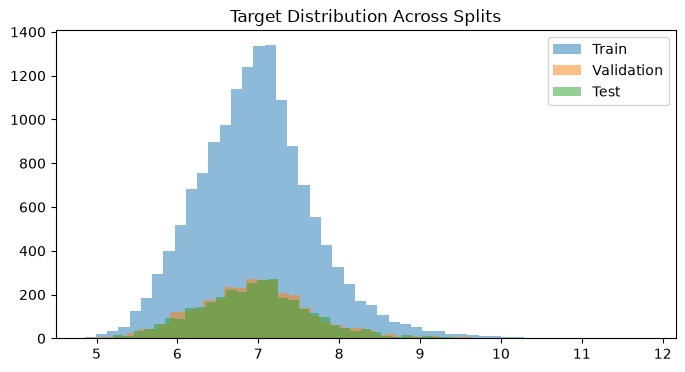

In [2]:
# TRAIN / VALIDATION / TEST SPLIT


# Separate features and target
X = df_model[MODEL_FEATURES]
y = df_model["log_price"]

# Split dataset into training, validation, and test sets
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    X,
    y,
    test_size=0.15,
    validation_size=0.15,
    random_state=42
)

# Validate dataset shapes
print("============= DATASET SPLITS =============")

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print()

print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")
print(f"y_test:  {y_test.shape}")


# Validate target distributions
print("\n============= TARGET DISTRIBUTION =============\n")

# Combine distributions into one table
summary = pd.concat([
    y_train.describe().to_frame(name="Train"),
    y_val.describe().to_frame(name="Validation"),
    y_test.describe().to_frame(name="Test")
], axis=1)

print(summary)

# Visualize distributions
plt.figure(figsize=(8,4))

plt.hist(y_train, bins=50, alpha=0.5, label="Train")
plt.hist(y_val, bins=50, alpha=0.5, label="Validation")
plt.hist(y_test, bins=50, alpha=0.5, label="Test")

plt.legend()
plt.title("Target Distribution Across Splits")

plt.show()

La partición de los datos se realizó exitosamente siguiendo la estrategia definida de **70% entrenamiento, 15% validación y 15% prueba**, obteniendo 15,015 observaciones para entrenamiento, 3,217 para validación y 3,218 para prueba.

Adicionalmente, se verificó la distribución de la variable objetivo (`log_price`) en cada subconjunto. Los estadísticos descriptivos muestran valores muy similares en términos de media, mediana, desviación estándar y percentiles, lo que indica que los tres conjuntos conservan una distribución consistente del precio transformado.

En particular, la media de `log_price` se mantiene cercana a 6.97 en los tres conjuntos, mientras que la desviación estándar permanece alrededor de 0.73. De forma similar, los percentiles 25, 50 y 75 presentan diferencias mínimas entre entrenamiento, validación y prueba.

Estos resultados sugieren que la partición fue adecuada y que no existen diferencias significativas entre los subconjuntos. Como consecuencia, los modelos podrán entrenarse, optimizarse y evaluarse sobre muestras representativas de la misma población, permitiendo una estimación más confiable de su capacidad de generalización.

### Pipeline de preprocesamiento

In [3]:
# PREPROCESSING PIPELINE

# Import preprocessing pipeline
from src.preprocess.preprocess_features import (
    fit_preprocessing_pipeline,
    transform_preprocessing_pipeline
)

# Fit preprocessing components using only training data
preprocessors = fit_preprocessing_pipeline(
    X_train
)

# Transform training set
X_train_processed = transform_preprocessing_pipeline(
    X_train,
    preprocessors
)

# Transform validation set
X_val_processed = transform_preprocessing_pipeline(
    X_val,
    preprocessors
)

# Transform test set
X_test_processed = transform_preprocessing_pipeline(
    X_test,
    preprocessors
)

# Display resulting shapes
print("=" * 50)
print("PREPROCESSING COMPLETED")
print("=" * 50)

print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_val_processed:   {X_val_processed.shape}")
print(f"X_test_processed:  {X_test_processed.shape}")

# Check for missing values
print()
print("=" * 50)
print("MISSING VALUES CHECK")
print("=" * 50)

print(f"Train missing values: {X_train_processed.isna().sum().sum()}")
print(f"Validation missing values: {X_val_processed.isna().sum().sum()}")
print(f"Test missing values: {X_test_processed.isna().sum().sum()}")

# Summary statistics of processed training set
pd.set_option("display.max_columns", None)
print()
print("=" * 50)
print("TRAINING DATA SUMMARY STATISTICS")
print("=" * 50)
X_train_processed.describe(include="all")

PREPROCESSING COMPLETED
X_train_processed: (15015, 30)
X_val_processed:   (3217, 30)
X_test_processed:  (3218, 30)

MISSING VALUES CHECK
Train missing values: 0
Validation missing values: 0
Test missing values: 0

TRAINING DATA SUMMARY STATISTICS


,amenity_score,commercial_within_radius,host_is_superhost,instant_bookable,has_tv,has_elevator,has_free_parking,has_coffee_maker,has_outdoor_furniture,has_air_conditioning,has_self_check_in,has_pool,accommodates_log,bathrooms_log,beds_log,bedrooms_log,dist_to_nearest_attraction_log,attractions_within_radius_log,calculated_host_listings_count_entire_homes_log,calculated_host_listings_count_private_rooms_log,minimum_nights_segment_ord,host_verifications_grouped_ord,review_scores_mean_segment_ord,host_total_listings_segment_ord,neighbourhood_cleansed_freq,property_group_room_freq,room_type_entire_home/apt,room_type_hotel_room,room_type_private_room,room_type_shared_room
count,15015.000000,1.501500e+04,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,1.501500e+04,1.501500e+04,15015.000000,1.501500e+04,15015.000000,1.501500e+04,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,15015.000000,1.501500e+04,1.501500e+04,15015.000000,15015.000000,15015.000000,15015.000000
mean,0.499593,8.068434e-17,0.414719,0.458208,0.860473,0.358175,0.304229,0.682118,0.227772,0.093040,0.589344,0.075191,1.798243e-17,-3.757382e-16,0.725259,3.217909e-17,0.242929,1.963871e-17,0.218908,0.591821,0.120346,2.024642,0.757975,1.461871,2.650043e-16,-4.694362e-16,0.685781,0.002597,0.300766,0.010856
std,0.207012,1.000033e+00,0.492690,0.498267,0.346507,0.479480,0.460095,0.465669,0.419409,0.290499,0.491969,0.263709,1.000033e+00,1.000033e+00,0.975208,1.000033e+00,0.805023,1.000033e+00,0.894174,0.885318,0.384315,0.474674,1.035357,1.138121,1.000033e+00,1.000033e+00,0.464220,0.050900,0.458606,0.103628
min,0.000000,-1.220334e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.601855e+00,-3.132214e+00,-1.709511,-2.784440e+00,-0.878577,-1.160175e+00,-0.730423,0.000000,0.000000,0.000000,-1.000000,0.000000,-1.414999e+00,-1.627649e+00,0.000000,0.000000,0.000000,0.000000
25%,0.353136,-8.842348e-01,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.531512e-01,-5.734838e-01,0.000000,-5.654137e-01,-0.339974,-1.160175e+00,-0.269577,0.000000,0.000000,2.000000,0.000000,0.000000,-9.128766e-01,-1.081395e+00,0.000000,0.000000,0.000000,0.000000
50%,0.533257,-2.190389e-01,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.996499e-02,-5.734838e-01,0.000000,-5.654137e-01,0.000000,1.282544e-01,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,-5.845283e-01,7.630026e-01,1.000000,0.000000,0.000000,0.000000
75%,0.657083,6.842272e-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,5.420745e-01,9.232776e-01,1.000000,7.326338e-01,0.660026,9.411631e-01,0.730423,1.000000,0.000000,2.000000,2.000000,2.000000,9.898511e-01,7.630026e-01,1.000000,0.000000,1.000000,0.000000
max,1.000000,2.630801e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.405454e+00,8.106542e+00,7.449284,9.104111e+00,3.826978,1.754072e+00,2.861598,3.892789,2.000000,3.000000,2.000000,3.000000,9.898511e-01,7.630026e-01,1.000000,1.000000,1.000000,1.000000


## 4. Métricas de Evaluación de Estrategia de Validación

Antes de entrenar los modelos, es necesario definir los criterios que se utilizarán para evaluar su desempeño y comparar sus resultados de manera consistente. Dado que el objetivo del proyecto consiste en predecir una variable numérica continua (`log_price`), se utilizarán métricas estándar para problemas de regresión. Cada métrica proporciona una perspectiva diferente sobre la calidad de las predicciones, por lo que se analizarán de forma complementaria.

### Métricas de evaluación

- **R² Score (Coefficient of Determination)**

    El coeficiente de determinación mide la proporción de la variabilidad de la variable objetivo que es explicada por el modelo a partir de las variables predictoras (características).

    Interpretación de los valores de *R²* :

    - **R² = 1.0**: Representa un ajuste perfecto. El modelo explica toda la variabilidad de los datos. Todas las predicciones coinciden exactamente con los valores reales.
    - **R² entre 0.7 y 0.9**: Indica un muy buen ajuste. El modelo es capaz de explicar la gran mayoría de la varianza en los datos, por lo que es altamente confiable para hacer predicciones.
    - **R² = 0** Indica que el modelo no aporta nada. Es equivalente a simplemente predecir el valor promedio de la variable objetivo para todos los casos, sin importar las características.
    - **R² <> 0**  Indica un modelo deficiente. Significa que el modelo es peor que simplemente trazar una línea horizontal en el promedio. A menudo ocurre cuando el modelo está mal configurado o no se ajusta a la naturaleza de los datos.

    Dado que permite evaluar la capacidad explicativa global del modelo, *R²* será la métrica principal para comparar modelos candidatos*

- **RMSE (Root Mean Squared Error)**

    RMSE mide la magnitud promedio de los errores de predicción penalizando con mayor fuerza los errores grandes. Esta métrica es especialmente útil cuando se desea identificar modelos que minimicen errores significativos en las estimaciones de precio.

    Debido a que el modelo se entrena sobre `log_price`, el RMSE será calculado inicialmente en escala logarítmica. Adicionalmente, para facilitar la interpretación de resultados, se convertirá posteriormente a unidades monetarias reales.


- **MAE (Mean Absolute Error)**

    *MAE* representa el error absoluto promedio entre los valores reales y las predicciones del modelo. A diferencia de RMSE, todos los errores reciben la misma penalización, por lo que proporciona una medida más robusta y fácil de interpretar del error típico esperado.

    Al igual que RMSE, esta métrica será reportada tanto en escala logarítmica como en precios reales.

### Estrategia de validación

Para evaluar correctamente la capacidad de generalización de los modelos, se utilizará una estrategia basada en tres conjuntos de datos:

- **Training Set:** entrenamiento de los modelos.
- **Validation Set:** comparación de modelos y optimización de hiperparámetros.
- **Test Set:** evaluación final del modelo seleccionado.

Además, se aplicará ***K-Fold Cross Validation*** (5 folds) durante la evaluación de los modelos candidatos y durante los procesos de optimización de hiperparámetros.

La validación cruzada permitirá medir la estabilidad de los resultados a través de múltiples particiones del conjunto de entrenamiento, reduciendo la dependencia de una única división de los datos y proporcionando una estimación más robusta del desempeño esperado.

Finalmente, el conjunto de prueba permanecerá completamente aislado durante el desarrollo del proyecto y será utilizado únicamente para la evaluación final del modelo ganador.

## 5. Modelo Base: Linear Regression

### Entrenamiento del modelo

El primer modelo evaluado será una **Regresión Lineal**, utilizada como modelo baseline de referencia para el resto del proyecto. La elección de este algoritmo se debe a su simplicidad, interpretabilidad y amplia utilización en problemas de regresión. Aunque su capacidad para modelar relaciones complejas es limitada, proporciona un punto de comparación fundamental para determinar si modelos más avanzados como Random Forest o XGBoost aportan una mejora significativa en el desempeño predictivo.

Además, debido a que la variable objetivo (`log_price`) presenta una distribución más cercana a la normalidad tras la transformación logarítmica aplicada, la Regresión Lineal constituye una primera aproximación razonable al problema.

En esta sección se entrenará el modelo utilizando el conjunto de entrenamiento y posteriormente se generarán predicciones sobre los conjuntos de entrenamiento (`X_train_processed`) y validación (`X_val_processed`) para evaluar su capacidad de ajuste y generalización.

In [4]:
# train baseline regression model
lr_model = train_model(
    LinearRegression(),
    X_train_processed,
    y_train
)

### Evaluación de desempeño

Una vez entrenado el modelo baseline, es necesario evaluar su capacidad predictiva sobre los conjuntos de entrenamiento y validación. Para ello se utilizarán las métricas definidas previamente: **R²**, **RMSE** y **MAE**. Estas métricas permitirán analizar tanto la capacidad explicativa del modelo como la magnitud de sus errores de predicción.

Adicionalmente, debido a que el modelo fue entrenado sobre la variable objetivo transformada (`log_price`), se calcularán métricas complementarias en la escala original de precios. Esto facilitará la interpretación práctica de los resultados al expresar los errores directamente en unidades monetarias.

Finalmente, la comparación entre las métricas de entrenamiento y validación permitirá identificar posibles señales tempranas de sobreajuste o subajuste antes de avanzar hacia modelos más complejos.

In [5]:
# evaluate model performance on train/validation sets
lr_eval_results = evaluate_model(
    model= lr_model,
    X_train= X_train_processed,
    y_train= y_train,
    X_val= X_val_processed,
    y_val= y_val,
    model_name= "Linear Regression",
    target_transform= np.expm1
)


LINEAR REGRESSION PERFORMANCE

TRAINING SET
R²:   0.5748
RMSE: 0.4784
MAE:  0.3498

VALIDATION SET
R²:   0.5941
RMSE: 0.4647
MAE:  0.3473

REAL PRICE METRICS (VALIDATION)
RMSE ($): $2,066.56
MAE ($):  $564.05


La Regresión Lineal obtuvo un R² de 0.5748 en entrenamiento y 0.5941 en validación, lo que indica que el modelo es capaz de explicar aproximadamente el 59% de la variabilidad observada en los precios de las propiedades Airbnb. Un aspecto positivo es que las métricas de entrenamiento y validación son muy similares. La diferencia entre ambos conjuntos es mínima tanto en R² como en RMSE y MAE, lo que sugiere que el modelo no presenta señales evidentes de sobreajuste y mantiene un comportamiento consistente sobre datos no vistos.

En cuanto a las métricas de error en el conjunto de validación, el modelo obtuvo:

- **RMSE** de $2,066.56 MXN
- **MAE** de $564.05 MXN 

El MAE indica que, en promedio, las predicciones difieren aproximadamente $564 MXN del precio real de una propiedad. Esta métrica proporciona una estimación intuitiva del error típico esperado al utilizar el modelo.

Por otro lado, el RMSE es considerablemente mayor que el MAE. El RMSE obtenido en la escala original de precios fue de $2,066.56 MXN. A diferencia del MAE, esta métrica penaliza con mayor intensidad los errores de gran magnitud, por lo que resulta especialmente sensible a observaciones atípicas o propiedades con precios extremos.

La diferencia observada entre RMSE y MAE sugiere que:

- Aunque la mayoría de las predicciones presentan errores moderados, existe un conjunto reducido de propiedades para las cuales el modelo comete errores significativamente mayores. 
- Hay segmentos específicos (como propiedades de lujo, hoteles o zonas preimum) donde la regresión lineal falla sistemáticamente.
- La relación entre algunas variables y el precio podría ser fuertemente no lineal.

Este comportamiento es común en problemas de predicción de precios, donde alojamientos de lujo o propiedades con características poco frecuentes suelen ser más difíciles de modelar mediante relaciones lineales simples.

En conjunto, estos resultados muestran que la Regresión Lineal constituye un baseline sólido y proporciona un punto de referencia útil para evaluar si modelos más avanzados son capaces de capturar relaciones no lineales y mejorar la precisión de las predicciones.

### Validación cruzada

Aunque las métricas obtenidas sobre el conjunto de validación proporcionan una estimación del desempeño del modelo, estas dependen de una única partición de los datos. Como resultado, los resultados pueden verse influenciados por la forma específica en que se realizó la división entre entrenamiento y validación.

Para obtener una evaluación más robusta y confiable, se aplicará ***K-Fold Cross Validation*** sobre el conjunto de entrenamiento. Esta técnica divide los datos en múltiples particiones (folds), entrenando y evaluando el modelo varias veces sobre diferentes subconjuntos de datos.

El objetivo es estimar la estabilidad y capacidad de generalización del modelo a través de distintas muestras del dataset. Además del desempeño promedio, la variabilidad entre folds permitirá identificar si los resultados obtenidos son consistentes o si dependen excesivamente de una partición específica.

En este proyecto se utilizará una validación cruzada de 5 folds, reportando la media y desviación estándar del coeficiente de determinación (R²).

In [6]:
# cross-validate model for robust performance estimation
lr_cv_results = cross_validate_model(
    model=lr_model,
    X=X_train_processed,
    y=y_train,
    cv=5
)


FOLD CROSS VALIDATION RESULTS
Fold 1: 0.5792
Fold 2: 0.5780
Fold 3: 0.5777
Fold 4: 0.5714
Fold 5: 0.5531

Mean R² R2: 0.5719
Std R² R2:  0.0098


La validación cruzada de 5 folds produjo valores de R² consistentes entre las diferentes particiones del conjunto de entrenamiento, con resultados comprendidos entre 0.56 y 0.59.

El modelo obtuvo un R² promedio de 0.5714, muy cercano al desempeño observado previamente sobre los conjuntos de entrenamiento y validación. Esta similitud sugiere que las métricas obtenidas durante la evaluación inicial son representativas del comportamiento general del modelo y no dependen de una partición específica de los datos.

Asimismo, la desviación estándar de 0.0089 indica una variabilidad muy reducida entre folds. Esto significa que el desempeño del modelo permanece estable cuando se entrena y evalúa sobre diferentes subconjuntos del dataset.

En conjunto, los resultados de la validación cruzada proporcionan evidencia adicional de que la Regresión Lineal presenta una capacidad de generalización consistente, estableció una línea base estable con capacidad predictiva moderable y no muestra señales de sobreajuste. Sin embargo, el nivel de desempeño alcanzado también sugiere que aún existe margen de mejora para que modelos basados en árboles capturen patrones más complejos y mejoren el desempeño predictivo.

### Interpretación de coeficientes

Una de las principales ventajas de la Regresión Lineal es su interpretabilidad. A diferencia de modelos más complejos, este algoritmo permite analizar directamente la contribución de cada variable a la predicción del precio.

Los coeficientes aprendidos por el modelo representan la dirección y magnitud de la relación entre cada feature y la variable objetivo (`log_price`), manteniendo constantes las demás variables del modelo.

- Un coeficiente positivo indica que valores mayores de la variable tienden a incrementar el precio estimado.
- Un coeficiente negativo indica que valores mayores de la variable tienden a reducir el precio estimado.
- Coeficientes cercanos a cero sugieren una contribución limitada dentro del modelo.

Debido a que las variables fueron transformadas y escaladas durante la etapa de *Feature Engineering*, los coeficientes no deben interpretarse como cambios monetarios directos. Sin embargo, sí permiten identificar qué características ejercen una mayor influencia positiva o negativa sobre las predicciones del modelo.

A continuación se analizan las variables con mayor impacto dentro de la Regresión Lineal entrenada.

In [7]:
# LINEAR REGRESSION COEFFICIENT ANALYSIS

# Create coefficient dataframe
coef_df = pd.DataFrame({
    "feature": X_train_processed.columns,
    "coefficient": lr_model.coef_
})

# Absolute importance
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# Sort by absolute magnitude
coef_df = coef_df.sort_values(
    by="abs_coefficient",
    ascending=False
)

# Top positive coefficients
top_positive = (
    coef_df
    .sort_values(by="coefficient", ascending=False)
    .head(10)
)

# Top negative coefficients
top_negative = (
    coef_df
    .sort_values(by="coefficient", ascending=True)
    .head(10)
)

print("=" * 50)
print("TOP POSITIVE COEFFICIENTS")
print("=" * 50)
print(top_positive[["feature", "coefficient"]])
print()

print("=" * 50)
print("TOP NEGATIVE COEFFICIENTS")
print("=" * 50)
print(top_negative[["feature", "coefficient"]])
print()

print("=" * 50)
print("LARGEST ABSOLUTE COEFFICIENTS")
print("=" * 50)
print(
    coef_df[
        ["feature", "coefficient", "abs_coefficient"]
    ].head(15)
)

TOP POSITIVE COEFFICIENTS
                      feature  coefficient
27       room_type_hotel_room     0.653851
9        has_air_conditioning     0.359407
26  room_type_entire_home/apt     0.257935
12           accommodates_log     0.250990
11                   has_pool     0.168940
4                      has_tv     0.151810
8       has_outdoor_furniture     0.134103
1    commercial_within_radius     0.117303
6            has_free_parking     0.114670
15               bedrooms_log     0.101712

TOP NEGATIVE COEFFICIENTS
                                             feature  coefficient
29                             room_type_shared_room    -0.893478
0                                      amenity_score    -0.124255
24                       neighbourhood_cleansed_freq    -0.080061
16                    dist_to_nearest_attraction_log    -0.064648
25                          property_group_room_freq    -0.060512
14                                          beds_log    -0.049796
19  calculat

El análisis de coeficientes permite identificar las variables que ejercen una mayor influencia sobre las predicciones de la Regresión Lineal.

**1. Coeficientes positivos**

Entre los coeficientes positivos más importantes destacan las variables relacionadas con el tipo de alojamiento y ciertas amenidades. En particular, las propiedades clasificadas como `Hotel Room` y `Entire Home/Apt` presentan una asociación positiva importante con el precio, lo que sugiere que estos tipos de alojamiento tienden a ubicarse en segmentos de mayor valor dentro del mercado analizado.

Asimismo, variables como `accommodates_log`, `has_air_conditioning`, `has_pool`, `has_tv`, `has_free_parking` y `has_outdoor_furniture` muestran contribuciones positivas relevantes. Este comportamiento resulta consistente con la lógica de negocio, ya que propiedades con mayor capacidad de huéspedes y amenidades adicionales suelen justificar precios más elevados.

**2. Coeficientes negativos**

Por otro lado, los coeficientes negativos más importantes corresponden principalmente a `room_type_shared_room`, indicando que los alojamientos compartidos tienden a asociarse con precios significativamente menores en comparación con otras modalidades de hospedaje. De forma similar, `dist_to_nearest_attraction_log` presenta una relación negativa, lo que sugiere que propiedades ubicadas más lejos de los principales puntos de interés tienden a presentar precios inferiores.

También se observa una contribución negativa en variables relacionadas con la frecuencia de ciertas categorías o ubicaciones, como `neighbourhood_cleansed_freq` y `property_group_room_freq`. Esto podría indicar que categorías más comunes dentro del dataset tienden a concentrarse en segmentos de menor precio.

**3. Coeficientes de `amenity_score` y `bathrooms_log`**

Aunque los coeficientes permiten analizar la dirección de la relación entre las variables y el precio, estos no deben interpretarse de forma aislada. Algunas variables del modelo contienen información relacionada o parcialmente redundante, por lo que la Regresión Lineal distribuye la contribución explicativa entre ellas.

Por ejemplo, durante las etapas previas del proyecto, variables como `amenity_score` y `bathrooms_log` mostraron una señal predictiva importante mediante análisis de correlación, información mutua y feature importance. Sin embargo, en el análisis de coeficientes su contribución aparece reducida o incluso cambia de signo debido a la presencia simultánea de variables relacionadas, como amenidades individuales (`has_tv`, `has_pool`, `has_air_conditioning`, etc.) o variables asociadas a la capacidad y características de la propiedad.

Por esta razón, los coeficientes deben interpretarse como una medida de influencia dentro del conjunto completo de variables del modelo y no como una medida absoluta de importancia predictiva.

En términos generales, los coeficientes obtenidos reflejan patrones coherentes con el mercado de alojamiento temporal: propiedades completas, con mayor capacidad, mejor equipadas y ubicadas en zonas con mayor actividad comercial tienden a asociarse con precios más altos, mientras que alojamientos compartidos o más alejados de las principales atracciones presentan precios inferiores.

## 6. Modelo: Random Forest Regressor

### Entrenamiento del modelo

El segundo modelo evaluado será un **Random Forest Regressor**, un algoritmo basado en conjuntos de árboles de decisión que combina múltiples modelos individuales para generar una predicción más robusta y precisa.

A diferencia de la Regresión Lineal, Random Forest es capaz de capturar relaciones no lineales e interacciones complejas entre variables sin requerir una especificación explícita de dichas relaciones. Esta característica resulta especialmente útil en problemas de predicción de precios, donde factores como la ubicación, las amenidades y las características del alojamiento pueden influir de manera no lineal sobre el valor final de la propiedad.

Además, los modelos basados en árboles suelen ser menos sensibles a la presencia de correlaciones entre variables y pueden manejar de forma más efectiva combinaciones complejas de características.

En esta sección se entrenará un modelo Random Forest utilizando los mismos conjuntos de entrenamiento y validación empleados en el baseline, permitiendo una comparación directa entre ambos enfoques.

In [8]:
# train random forest regression model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
    )

rf_model = train_model(
    rf_model,
    X_train_processed,
    y_train
)

### Evaluación de desempeño

Una vez entrenado el modelo Random Forest, se evalúa su capacidad predictiva utilizando las mismas métricas empleadas en el modelo baseline. Esto permite realizar una comparación directa y consistente entre ambos enfoques. Al igual que en la Regresión Lineal, se analizarán las métricas de entrenamiento y validación para evaluar tanto el desempeño predictivo como la capacidad de generalización del modelo.

Además, se calcularán métricas complementarias en la escala original de precios con el fin de facilitar la interpretación práctica de los errores de predicción.

Dado que Random Forest posee una capacidad significativamente mayor para modelar relaciones complejas, también será importante comparar el desempeño entre entrenamiento y validación para identificar posibles señales de sobreajuste.

In [9]:
# evaluate model performance on train/validation sets
rf_eval_results = evaluate_model(
    model= rf_model,
    X_train= X_train_processed,
    y_train= y_train,
    X_val= X_val_processed,
    y_val= y_val,
    model_name= "Random Forest Regression",
    target_transform= np.expm1
)


RANDOM FOREST REGRESSION PERFORMANCE

TRAINING SET
R²:   0.9614
RMSE: 0.1441
MAE:  0.0978

VALIDATION SET
R²:   0.7635
RMSE: 0.3547
MAE:  0.2512

REAL PRICE METRICS (VALIDATION)
RMSE ($): $1,238.47
MAE ($):  $400.62


El modelo Random Forest obtuvo un R² de 0.9614 sobre el conjunto de entrenamiento y 0.7635 sobre el conjunto de validación, superando significativamente el desempeño alcanzado por la Regresión Lineal.

Esta mejora indica que el modelo es capaz de capturar relaciones no lineales e interacciones complejas entre variables que no pueden ser representadas adecuadamente mediante un enfoque lineal. Como resultado, la capacidad explicativa del modelo aumentó considerablemente, pasando de aproximadamente un 59% de la variabilidad explicada en el baseline a más de un 76% sobre datos no vistos.

En cuanto a las métricas de error, el modelo alcanzó un RMSE de 0.3547 y un MAE de 0.2512 sobre el conjunto de validación, mejorando ambas métricas respecto a la Regresión Lineal. Al convertir las predicciones nuevamente a la escala original de precios, se obtuvo un RMSE de \$1,238.47 MXN y un MAE de \$400.62 MXN. Esto representa una reducción importante del error respecto al modelo baseline (41% de reducción en RMSE y 29% en MAE). 

El hecho de que el RMSE haya mejorado más que el MAE sugiere que Random Forest está manejando mucho mejor los alojamientos Airbnb difíciles o atípicos que estaban generando errores grandes en la Regresión Lineal. También podemos afirmar que las relaciones entre las características de una propiedad Airbnb y su precio no son puramente lineales.

La diferencia observada entre entrenamiento y validación indica cierto grado de sobreajuste, comportamiento habitual en modelos basados en árboles debido a su elevada capacidad de aprendizaje. Sin embargo, el desempeño sobre validación continúa siendo significativamente superior al baseline, por lo que el modelo mantiene una buena capacidad de generalización.

### Validación cruzada

Después de eavluar el desempeño de Random Forest sobre el conjunto de validación, se realizará una validación cruzada de 5 folds para verificar la estabilidad de los resultados obtenidos y estimar con mayor robustez la capacidad de generalización del modelo.

Dado que el modelo mostró una diferencia apreciable entre el desempeño de entrenamiento y validación, esta evaluación permitirá determinar si el comportamiento observado se mantiene de forma consistente sobre distintas particiones de los datos o si depende excesivamente de una muestra específica.

In [10]:
# cross-validate model for robust performance estimation
rf_cv_results = cross_validate_model(
    model=rf_model,
    X=X_train_processed,
    y=y_train,
    cv=5
)


FOLD CROSS VALIDATION RESULTS
Fold 1: 0.7302
Fold 2: 0.7211
Fold 3: 0.7267
Fold 4: 0.7215
Fold 5: 0.6942

Mean R² R2: 0.7187
Std R² R2:  0.0127


La validación cruzada produjo valores de R² comprendidos entre 0.6942 y 0.7302, mostrando un desempeño relativamente consistente a través de las diferentes particiones del conjunto de entrenamiento.

El modelo obtuvo un R² promedio de 0.7187, confirmando que Random Forest mantiene una capacidad predictiva significativamente superior a la observada en la Regresión Lineal. Esto refuerza la evidencia de que una parte importante de la relación entre las características de los alojamientos y su precio puede explicarse mediante patrones no lineales e interacciones complejas entre variables.

La desviación estándar de 0.0127 indica una variabilidad reducida entre folds, lo que sugiere que el modelo responde de manera estable ante diferentes muestras de entrenamiento y validación. Aunque la dispersión es ligeramente superior a la observada en el modelo lineal, los resultados continúan siendo consistentes y muestran una buena capacidad de generalización.

Por otro lado, el desempeño promedio obtenido mediante validación cruzada es inferior al observado sobre el conjunto de validación individual. Esta diferencia, junto con el elevado R² alcanzado sobre entrenamiento, aporta evidencia adicional de cierto grado de sobreajuste. Sin embargo, el modelo continúa superando ampliamente al baseline en todas las evaluaciones realizadas.

En conjunto, los resultados indican que Random Forest representa una mejora sustancial respecto a la Regresión Lineal y constituye un candidato sólido para continuar con la etapa de optimización de hiperparámetros.

### Feature Importance

A diferencia de la Regresión Lineal, los modelos basados en árboles no generan coeficientes que permitan interpretar directamente la influencia de cada variable sobre la predicción. En su lugar, Random Forest proporciona una medida de **Feature Importance**, que estima cuánto contribuye cada variable a reducir el error durante el proceso de construcción de los árboles.

Esta métrica permite identificar cuáles son las características más relevantes para explicar el precio de una propiedad dentro del modelo. Es importante destacar que la importancia de variables no indica si una característica aumenta o disminuye el precio, sino únicamente cuánto contribuye al poder predictivo del modelo.

El análisis de importancia resulta especialmente útil para validar las conclusiones obtenidas durante la etapa de selección de variables y para comprender qué factores tienen mayor influencia en las decisiones del modelo.

In [11]:
# RANDOM FOREST FEATURE IMPORTANCE

# Create importance dataframe
rf_importance_df = pd.DataFrame({
    "feature": X_train_processed.columns,
    "importance": rf_model.feature_importances_
})

# Sort descending
rf_importance_df = rf_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Display results
print("=" * 50)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 50)

display(rf_importance_df)
print()

# Top 15 features
top_features_rf = rf_importance_df.head(15)

RANDOM FOREST FEATURE IMPORTANCE


,feature,importance
0,accommodates_log,0.168010
1,bathrooms_log,0.157547
2,room_type_entire_home/apt,0.090411
3,property_group_room_freq,0.067438
4,amenity_score,0.066821
5,dist_to_nearest_attraction_log,0.064409
6,commercial_within_radius,0.060141
7,bedrooms_log,0.050356
8,attractions_within_radius_log,0.040011
9,review_scores_mean_segment_ord,0.035295


El análisis de Feature Importance revela que las características más influyentes para la predicción del precio están relacionadas principalmente con la capacidad del alojamiento, el tamaño de la propiedad, el tipo de alojamiento, las amenidades y la ubicación.

**1. Variables de capacidad**

Las variables más importantes fueron `accommodates_log` y `bathrooms_log`, indicando que la capacidad de huéspedes y el número de baños constituyen algunos de los factores más relevantes para explicar las diferencias de precio entre propiedades. Este resultado es consistente con la lógica de negocio, ya que propiedades más amplias y con mayor capacidad suelen pertenecer a segmentos de mayor valor.

**2. Vairables del tipo de alojamiento**   

También destacan variables relacionadas con la categoría del alojamiento, como `room_type_entire_home/apt` y `property_group_room_freq`, lo que sugiere que el tipo de propiedad desempeña un papel importante en la formación del precio.

**3. Variables de ubicación**  

Las variables de ubicación continúan mostrando una contribución significativa. Factores como `dist_to_nearest_attraction_log`, `commercial_within_radius`, `attractions_within_radius_log` y `neighbourhood_cleansed_freq` aparecen entre las variables más relevantes, confirmando que la localización de la propiedad es uno de los principales determinantes del precio.

**4. Variable `amenity_score`**  

Asimismo, `amenity_score` mantiene una importancia elevada dentro del modelo, validando la utilidad de la variable creada durante la etapa de Feature Engineering. Esto indica que la calidad y cantidad de amenidades disponibles continúa aportando información predictiva relevante incluso después de incorporar múltiples características adicionales.


**5. Variables binarias**
Por otro lado, algunas variables binarias individuales como `has_tv`, `has_pool`, `has_coffee_maker` o `has_elevator` presentan importancias relativamente bajas. Esto sugiere que gran parte de la información asociada a las amenidades ya se encuentra capturada por variables más generales como `amenity_score`.

En conjunto, los resultados muestran que el modelo basa principalmente sus predicciones en factores estructurales de la propiedad (capacidad, tamaño y tipo), complementados por variables de ubicación y calidad de amenidades.

## 7. Modelo: XGBoost Regressor

### Entrenamiento del modelo

El tercer modelo evaluado será un XGBoost Regressor (Extreme Gradient Boosting), uno de los algoritmos de aprendizaje supervisado más utilizados en problemas de regresión y competiciones de Machine Learning debido a su capacidad para capturar patrones complejos y generar modelos altamente precisos.

A diferencia de Random Forest, que construye múltiples árboles de forma independiente y combina sus predicciones mediante agregación, XGBoost construye los árboles de manera secuencial. Cada nuevo árbol se entrena para corregir los errores cometidos por los árboles anteriores, permitiendo que el modelo aprenda progresivamente patrones cada vez más complejos presentes en los datos.

Además de su capacidad para modelar relaciones no lineales e interacciones entre variables, XGBoost incorpora mecanismos de regularización que ayudan a controlar el sobreajuste y mejorar la capacidad de generalización del modelo. Estas características suelen permitir un mejor equilibrio entre desempeño predictivo y robustez frente a datos no vistos.

En esta sección se entrenará un modelo XGBoost utilizando los mismos conjuntos de entrenamiento y validación empleados en los modelos anteriores, permitiendo comparar directamente su desempeño frente a la Regresión Lineal y Random Forest.

In [12]:
# train xgboost regression model
xgb_model = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

xgb_model = train_model(
    model=xgb_model,
    X_train=X_train_processed,
    y_train=y_train
)

### Evaluación de desempeño

Una vez entrenado el modelo XGBoost, se evaluará su capacidad predictiva utilizando las mismas métricas empleadas en los modelos anteriores. Esto permitirá realizar una comparación consistente entre la Regresión Lineal, Random Forest y XGBoost bajo las mismas condiciones experimentales.

Al igual que en las evaluaciones previas, se analizarán las métricas obtenidas sobre los conjuntos de entrenamiento y validación con el fin de evaluar tanto el desempeño predictivo como la capacidad de generalización del modelo. Asimismo, se calcularán métricas complementarias en la escala original de precios para facilitar la interpretación práctica de los errores de predicción y cuantificar el impacto real del modelo sobre el problema de negocio.

Dado que XGBoost incorpora mecanismos de aprendizaje secuencial y regularización, esta evaluación permitirá determinar si dichas características contribuyen a mejorar el equilibrio entre precisión predictiva y capacidad de generalización respecto a los modelos evaluados anteriormente.

In [13]:
# evaluate model performance on train/validation sets
xgb_eval_results = evaluate_model(
    model= xgb_model,
    X_train= X_train_processed,
    y_train= y_train,
    X_val= X_val_processed,
    y_val= y_val,
    model_name= "XGBoost Regressor",
    target_transform= np.expm1
)


XGBOOST REGRESSOR PERFORMANCE

TRAINING SET
R²:   0.8807
RMSE: 0.2534
MAE:  0.1820

VALIDATION SET
R²:   0.7623
RMSE: 0.3556
MAE:  0.2566

REAL PRICE METRICS (VALIDATION)
RMSE ($): $1,185.13
MAE ($):  $416.69


El modelo XGBoost obtuvo un R² de 0.8807 sobre el conjunto de entrenamiento y 0.7623 sobre el conjunto de validación, alcanzando un desempeño prácticamente equivalente al observado en Random Forest sobre datos no vistos. Estos resultados confirman que las relaciones entre las características de los alojamientos Airbnb y sus precios contienen patrones no lineales que pueden ser aprovechados por modelos basados en árboles. Tanto Random Forest como XGBoost logran capturar una proporción sustancialmente mayor de la variabilidad del precio en comparación con la Regresión Lineal.

En cuanto a las métricas de error, el modelo alcanzó un RMSE de 0.3556 y un MAE de 0.2566 sobre el conjunto de validación. Al transformar nuevamente las predicciones a la escala original de precios, se obtuvo un RMSE de \$1,185.13 MXN y un MAE de \$416.69 MXN.

Al comparar estos resultados con Random Forest, se observa un comportamiento interesante. Aunque ambos modelos presentan valores de R² prácticamente idénticos, XGBoost logra una ligera mejora en RMSE sobre la escala original, reduciendo los errores más grandes de predicción. Sin embargo, Random Forest mantiene una ventaja marginal en MAE, lo que sugiere un mejor desempeño promedio sobre la mayoría de los alojamientos evaluados.

Una diferencia relevante entre ambos modelos aparece al analizar el desempeño sobre entrenamiento. Mientras que Random Forest alcanzó un R² de 0.9614, XGBoost obtuvo un R² de 0.8807. Esta reducción de la brecha entre entrenamiento y validación indica que XGBoost presenta un menor grado de sobreajuste y un comportamiento más equilibrado entre capacidad predictiva y generalización.

En conjunto, los resultados muestran que XGBoost ofrece un desempeño competitivo respecto a Random Forest, manteniendo un nivel de precisión similar  mientras reduce significativamente el ajuste excesivo observado durante el entrenamiento. Esto lo convierte en un candidato sólido para continuar con la etapa de validación cruzada y optimización de hiperparámetros.

### Validación cruzada

Con el fin de mantener un proceso de evaluación consistente entre los distintos modelos candidatos, se aplicará la misma estrategia de validación cruzada utilizada previamente en la Regresión Lineal y Random Forest.

Esta evaluación permitirá verificar si el desempeño observado sobre el conjunto de validación se mantiene estable a través de diferentes particiones de los datos, proporcionando una estimación más robusta de la capacidad de generalización del modelo.

In [14]:
# cross-validate model for robust performance estimation
xgb_cv_results = cross_validate_model(
    model=xgb_model,
    X=X_train_processed,
    y=y_train,
    cv=5
)


FOLD CROSS VALIDATION RESULTS
Fold 1: 0.7280
Fold 2: 0.7331
Fold 3: 0.7357
Fold 4: 0.7183
Fold 5: 0.7001

Mean R² R2: 0.7230
Std R² R2:  0.0129


La validación cruzada produjo valores de R² comprendidos entre 0.7001 y 0.7357, mostrando un comportamiento consistente entre las diferentes particiones del conjunto de entrenamiento. El modelo obtuvo un R² promedio de 0.7230, ligeramente superior al alcanzado por Random Forest (0.7187). Aunque la diferencia es reducida, los resultados sugieren que XGBoost presenta una capacidad de generalización marginalmente mejor sobre distintas muestras del dataset.

La desviación estándar obtenida fue de 0.0129, prácticamente idéntica a la observada en Random Forest. Esto indica que ambos modelos presentan niveles de estabilidad muy similares y que su desempeño permanece consistente cuando son entrenados y evaluados sobre diferentes subconjuntos de datos. Asimismo, el R² promedio obtenido mediante validación cruzada se mantiene relativamente cercano al desempeño observado sobre el conjunto de validación (0.7623), lo que proporciona evidencia adicional de que las métricas obtenidas durante la evaluación inicial son representativas del comportamiento general del modelo.

Al comparar los resultados de los tres modelos evaluados hasta este punto, XGBoost presenta el mejor desempeño promedio en validación cruzada, seguido muy de cerca por Random Forest. Considerando además que XGBoost mostró una menor diferencia entre entrenamiento y validación durante la evaluación inicial, los resultados sugieren un mejor equilibrio entre capacidad predictiva y generalización.

En conjunto, la validación cruzada confirma que XGBoost constituye el modelo con mejor desempeño global entre los candidatos evaluados hasta el momento, convirtiéndose en un fuerte candidato para la etapa de optimización de hiperparámetros y selección del modelo final.

### Feature importance

En esta sección se analizará la importancia de variables estimada por XGBoost y se compararán los resultados obtenidos con los observados previamente en Random Forest, con el objetivo de identificar patrones consistentes entre ambos modelos basados en árboles.

Los modelos basados en árboles permiten estimar la importancia relativa de cada característica a partir de su contribución durante el proceso de construcción de los árboles. Esta información proporciona una visión complementaria sobre los factores que más influyen en la predicción del precio de los alojamientos y facilita la interpretación del modelo.

Si bien estas métricas no deben interpretarse como relaciones causales, sí permiten identificar qué variables contienen una mayor cantidad de señal predictiva dentro del conjunto de datos.

In [15]:
# XGBOOST FEATURE IMPORTANCE

# Create importance dataframe
xgb_importance_df = pd.DataFrame({
    "feature": X_train_processed.columns,
    "importance": xgb_model.feature_importances_
})

# Sort descending
xgb_importance_df = xgb_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Display results
print("=" * 50)
print("XGBOOST FEATURE IMPORTANCE")
print("=" * 50)

display(xgb_importance_df)
print()

XGBOOST FEATURE IMPORTANCE


,feature,importance
0,room_type_entire_home/apt,0.228671
1,accommodates_log,0.105774
2,bedrooms_log,0.105631
3,bathrooms_log,0.090909
4,property_group_room_freq,0.074214
5,room_type_shared_room,0.073686
6,has_air_conditioning,0.068807
7,attractions_within_radius_log,0.033385
8,review_scores_mean_segment_ord,0.021582
9,has_pool,0.020828


La importancia de variables obtenida mediante XGBoost muestra un patrón consistente con los resultados observados previamente en Random Forest, aunque con diferencias relevantes en la forma en que ambos modelos distribuyen la importancia entre las características disponibles.

**1. Variables con mayor importancia**

La variable más influyente fue `room_type_entire_home/apt`, concentrando aproximadamente el 22.9% de la importancia total del modelo. Este resultado sugiere que el hecho de ofrecer una vivienda completa constituye uno de los factores con mayor impacto sobre el precio de un alojamiento Airbnb. A continuación aparecen variables relacionadas con la capacidad y tamaño del inmueble, como `accommodates_log`, `bedrooms_log` y `bathrooms_log`, confirmando que la dimensión física de la propiedad continúa siendo uno de los principales determinantes del precio.

También destacan variables asociadas al tipo de propiedad y a las amenidades disponibles. En particular, `property_group_room_freq`, `has_air_conditioning`, `has_pool`, `has_tv` y otras características relacionadas con equipamiento muestran una contribución importante dentro del proceso de predicción. Estos resultados sugieren que la experiencia ofrecida por el alojamiento y el nivel de comodidad disponible influyen de manera significativa sobre el valor percibido por los huéspedes.

**2. Variables de ubicación**

Por otro lado, las variables relacionadas con la ubicación mantienen una presencia relevante dentro del modelo. Características como `attractions_within_radius_log`, `dist_to_nearest_attraction_log`, `commercial_within_radius` y `neighbourhood_cleansed_freq` aparecen nuevamente entre las variables más importantes, reforzando la idea de que la localización continúa siendo uno de los principales factores explicativos del precio.

**3. Variable `amenity_score`**

Un aspecto particularmente interesante aparece al analizar la variable `amenity_score`. Mientras que en Random Forest esta característica se ubicó entre las variables más importantes del modelo, en XGBoost su contribución relativa fue considerablemente menor. Este comportamiento sugiere que parte de la información capturada por el puntaje agregado de amenidades podría estar siendo explicada por otras variables más específicas presentes en el modelo, como `has_air_conditioning`, `has_pool`, `has_tv`, `has_free_parking` o `has_elevator`.

En otras palabras, Random Forest parece apoyarse más en la señal global proporcionada por el puntaje agregado de amenidades, mientras que XGBoost distribuye esa información entre características individuales que describen de manera más detallada los servicios ofrecidos por el alojamiento. Esta diferencia refleja distintos mecanismos de aprendizaje entre ambos algoritmos, aunque ambos llegan a conclusiones similares respecto a la relevancia general de las amenidades en la formación del precio.

Al comparar estos resultados con los obtenidos mediante Random Forest, se observa una elevada consistencia en las variables seleccionadas como más relevantes. Ambos modelos coinciden en destacar el tamaño del alojamiento, el tipo de propiedad, la ubicación, las amenidades y la reputación del anuncio como los principales impulsores del precio. Esta coincidencia entre modelos diferentes aporta mayor confianza sobre la validez de los patrones identificados durante el análisis.

## 8. Comparación de Modelos

Una vez completado el entrenamiento, evaluación y validación cruzada de los modelos candidatos, resulta necesario realizar una comparación consolidada de los resultados obtenidos.

El objetivo de esta sección es analizar el desempeño relativo de cada algoritmo utilizando las métricas consistentes de capacidad predictiva, estabilidad y error de predicción obtenidas durante el entrenamiento y evaluación. Esta comparación permitirá identificar las fortalezas y limitaciones de cada enfoque antes de avanzar a la etapa de optimización de hiperparámetros.

Para ello, se considerarán tanto las métricas obtenidas sobre el conjunto de validación como los resultados de validación cruzada, proporcionando una visión más completa del equilibrio entre precisión, generalización y robustez de cada modelo.

In [16]:
comparison_df = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Train R²": [
        lr_eval_results["train_r2"],
        rf_eval_results["train_r2"],
        xgb_eval_results["train_r2"]
    ],

    "Validation R²": [
        lr_eval_results["val_r2"],
        rf_eval_results["val_r2"],
        xgb_eval_results["val_r2"]
    ],

    "CV Mean R²": [
        lr_cv_results["mean"],
        rf_cv_results["mean"],
        xgb_cv_results["mean"]
    ],

    "CV Std": [
        lr_cv_results["std"],
        rf_cv_results["std"],
        xgb_cv_results["std"]
    ],

    "RMSE ($)": [
        lr_eval_results["val_rmse_real"],
        rf_eval_results["val_rmse_real"],
        xgb_eval_results["val_rmse_real"]
    ],

    "MAE ($)": [
        lr_eval_results["val_mae_real"],
        rf_eval_results["val_mae_real"],
        xgb_eval_results["val_mae_real"]
    ]
})

comparison_df.set_index('Model')

,Train R²,Validation R²,CV Mean R²,CV Std,RMSE ($),MAE ($)
Model,,,,,,
Linear Regression,0.574832,0.594103,0.571883,0.009791,2066.564247,564.047297
Random Forest,0.961444,0.763486,0.718736,0.012708,1238.473784,400.621776
XGBoost,0.880710,0.762301,0.723041,0.012935,1185.126526,416.688092


Los resultados muestran una mejora sustancial al pasar de la Regresión Lineal a los modelos basados en árboles. Mientras que el modelo baseline logró explicar aproximadamente el 59% de la variabilidad observada en los precios (R² = 0.5941), tanto Random Forest como XGBoost alcanzaron valores cercanos al 76% sobre el conjunto de validación, evidenciando su capacidad para capturar relaciones no lineales e interacciones complejas presentes en los datos.

La validación cruzada confirma esta tendencia. Tanto Random Forest como XGBoost obtuvieron valores promedio de R² superiores a 0.71, superando ampliamente el desempeño observado en la Regresión Lineal. Además, los tres modelos presentaron desviaciones estándar reducidas, lo que indica que los resultados son consistentes entre diferentes particiones de los datos y no dependen de una muestra específica.

Al comparar los dos modelos basados en árboles, se observa que ambos alcanzan un desempeño muy similar sobre el conjunto de validación. Sin embargo, XGBoost obtuvo el mayor R² promedio en validación cruzada (0.7230 frente a 0.7187) y el menor RMSE en la escala original de precios (\$1,185 MXN frente a \$1,238 MXN). Estos resultados sugieren una ligera ventaja de XGBoost en términos de capacidad predictiva global. Por otro lado, Random Forest alcanzó un MAE ligeramente inferior ($400.62 MXN frente a $416.69 MXN), lo que indica que sus errores promedio son marginalmente menores para la mayoría de las observaciones. No obstante, XGBoost parece manejar mejor los errores más grandes, reflejado en su menor RMSE.

También resulta relevante analizar la diferencia entre desempeño de entrenamiento y validación. Random Forest presentó el mayor nivel de sobreajuste, alcanzando un R² de 0.9614 sobre entrenamiento frente a 0.7635 sobre validación. En contraste, XGBoost mostró una brecha considerablemente menor (0.8807 frente a 0.7623), sugiriendo un mejor equilibrio entre capacidad de aprendizaje y generalización.

En conjunto, los resultados posicionan a Random Forest y XGBoost como los modelos más competitivos entre los candidatos evaluados. Ambos algoritmos muestran una mejora sustancial respecto a la Regresión Lineal y alcanzan niveles de desempeño muy similares sobre los conjuntos de validación y validación cruzada. Si bien XGBoost presenta una ligera ventaja en términos de capacidad de generalización y error global de predicción, las diferencias observadas respecto a Random Forest son relativamente reducidas. Por esta razón, ninguno de los dos modelos puede considerarse claramente superior en esta etapa del proyecto.

En consecuencia, ambos modelos avanzarán a la fase de optimización de hiperparámetros, donde se buscará maximizar su desempeño y determinar de forma objetiva cuál ofrece el mejor equilibrio entre precisión predictiva, estabilidad y capacidad de generalización para el problema de predicción de precios de Airbnb.

## 9. Optimización de Hiperparámetros

Hasta este punto, los modelos candidatos han sido evaluados utilizando configuraciones relativamente simples y cercanas a los valores por defecto de cada algoritmo. Si bien este enfoque permite realizar una comparación inicial justa entre modelos, no garantiza que cada uno esté operando bajo las condiciones que maximizan su desempeño.

La optimización de hiperparámetros tiene como objetivo identificar combinaciones de configuración que permitan mejorar la capacidad predictiva y la generalización de los modelos. A diferencia de los parámetros aprendidos durante el entrenamiento, los hiperparámetros controlan aspectos fundamentales del proceso de aprendizaje, como la complejidad del modelo, la profundidad de los árboles o la cantidad de estimadores utilizados.

Dado que Random Forest y XGBoost obtuvieron resultados muy similares durante la etapa de comparación de modelos, ambos serán sometidos a un proceso de optimización utilizando Randomized Search Cross Validation (`RandomizedSearchCV`), en lugar de una búsqueda exhaustiva mediante Grid Search (`GridSearchCV`). Este enfoque permite explorar de forma eficiente distintas configuraciones de hiperparámetros mediante validación cruzada, identificando aquellas combinaciones que ofrecen el mejor desempeño promedio sobre diferentes particiones de los datos, reduciendo significativamente el costo computacional sin comprometer la calidad de los resultados.

`RandomizedSearchCV` evalúa un número fijo de configuraciones de parámetros (n_iter), lo que lo hace computacionalmente más económico que `GridSearchCV`. Dado que el objetivo del proyecto es identificar configuraciones competitivas de manera eficiente y reproducible, `RandomizedSearchCV` proporciona un equilibrio adecuado entre desempeño, tiempo de ejecución y capacidad de exploración del espacio de búsqueda.

Los modelos optimizados serán posteriormente reevaluados y comparados para determinar cuál de ellos presenta el mejor equilibrio entre precisión predictiva, estabilidad y capacidad de generalización.

### Optimización: Random Forest Regressor

In [23]:
# RANDOM FOREST HYPERPARAMETER TUNING

# Path used to save/load the RandomizedSearchCV object
search_path = Path("../models/tuning/rf_searchcv.joblib")

# Create destination directory if it does not exist
search_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Load previous search if available
if search_path.exists():

    print(">>> Loading saved RandomizedSearchCV object...")

    rf_searchcv = joblib.load(search_path)

    print(
        f">>> Loaded successfully from: {search_path}"
    )

    print(
        f">>> Best CV R²: "
        f"{rf_searchcv.best_score_:.4f}"
    )

# Otherwise run hyperparameter tuning
else:

    print(
        ">>> Running RandomizedSearchCV "
        "for Random Forest..."
    )

    rf_searchcv = tune_model(
        model=RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        param_distributions=RF_PARAM_GRID,
        X_train=X_train_processed,
        y_train=y_train,
        n_iter=50,
        cv=5
    )

    print()
    print(">>> Search completed. Saving results...")

    joblib.dump(
        rf_searchcv,
        search_path
    )

    print(
        f">>> Saved successfully to: {search_path}"
    )

# Extract optimized model
rf_tuned = rf_searchcv.best_estimator_

# Save tuned model in candidates folder
candidates_path = Path("../models/candidates/rf_model_tuned.joblib")
candidates_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(rf_tuned, candidates_path)
print(f">>> Tuned model saved to: {candidates_path}")

# Display best parameters and score
print()
print("=" * 50)
print("BEST RANDOM FOREST PARAMETERS")
print("=" * 50)
print()

print("Best Parameters:")
print(rf_searchcv.best_params_)

print()
print(
    f"Best Cross-Validation R²: "
    f"{rf_searchcv.best_score_:.4f}"
)

>>> Loading saved RandomizedSearchCV object...
>>> Loaded successfully from: ..\models\tuning\rf_searchcv.joblib
>>> Best CV R²: 0.7295
>>> Tuned model saved to: ..\models\candidates\rf_model_tuned.joblib

BEST RANDOM FOREST PARAMETERS

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}

Best Cross-Validation R²: 0.7295


La optimización de hiperparámetros mediante Randomized Search permitió identificar una configuración con mejor desempeño promedio que la utilizada inicialmente para el modelo Random Forest. Entre las 50 combinaciones evaluadas mediante validación cruzada de 5 folds, la mejor configuración obtuvo un R² promedio de 0.7295. Este resultado supera el R² promedio de 0.7187 observado previamente en la versión base del modelo, lo que indica que existe margen de mejora mediante un ajuste adecuado de los hiperparámetros.

La configuración seleccionada incrementa el número de árboles a 300 y limita parcialmente la complejidad individual de cada árbol mediante una profundidad máxima de 30 niveles y un mínimo de 5 observaciones para realizar divisiones internas. Adicionalmente, el uso de `max_features="sqrt"` introduce una mayor aleatoriedad durante la construcción del bosque, favoreciendo la diversidad entre árboles y reduciendo el riesgo de sobreajuste.

Aunque la mejora observada en validación cruzada es moderada, los resultados sugieren que el modelo optimizado presenta un mejor equilibrio entre capacidad predictiva y generalización que la versión inicial de Random Forest. En la siguiente sección se evaluará el desempeño del modelo optimizado sobre los conjuntos de entrenamiento y validación para determinar si estas mejoras se traducen en un mejor desempeño sobre datos no vistos durante el entrenamiento.

In [18]:
# evaluate model performance on train/validation sets
rf_tuned_eval_results = evaluate_model(
    model= rf_tuned,
    X_train= X_train_processed,
    y_train= y_train,
    X_val= X_val_processed,
    y_val= y_val,
    model_name= "Random Forest Tuned",
    target_transform= np.expm1
)

# cross-validate model for robust performance estimation
rf_tuned_cv_results = cross_validate_model(
    model=rf_tuned,
    X=X_train_processed,
    y=y_train,
    cv=5
)


RANDOM FOREST TUNED PERFORMANCE

TRAINING SET
R²:   0.9230
RMSE: 0.2036
MAE:  0.1391

VALIDATION SET
R²:   0.7723
RMSE: 0.3480
MAE:  0.2506

REAL PRICE METRICS (VALIDATION)
RMSE ($): $1,415.75
MAE ($):  $414.17

FOLD CROSS VALIDATION RESULTS
Fold 1: 0.7297
Fold 2: 0.7383
Fold 3: 0.7370
Fold 4: 0.7289
Fold 5: 0.7137

Mean R² R2: 0.7295
Std R² R2:  0.0088


El modelo Random Forest optimizado obtuvo un R² de 0.9230 sobre el conjunto de entrenamiento y 0.7723 sobre el conjunto de validación. Comparado con la versión original del modelo, el desempeño sobre validación mejoró de 0.7635 a 0.7723, mientras que el desempeño sobre entrenamiento disminuyó de 0.9614 a 0.9230. Este comportamiento es una señal positiva, ya que indica que la optimización de hiperparámetros logró reducir parte del sobreajuste presente en la versión inicial del modelo. Aunque el modelo ahora ajusta menos agresivamente los datos de entrenamiento, su capacidad para generalizar hacia datos no vistos es superior.

Las métricas de error también muestran una ligera mejora. El RMSE de validación disminuyó de 0.3547 a 0.3480 y el MAE pasó de 0.2512 a 0.2506, confirmando que las predicciones son marginalmente más precisas que las obtenidas por el Random Forest original. Al transformar nuevamente las predicciones a la escala real de precios, el modelo alcanzó un RMSE de \$1,415.75 MXN y un MAE de \$414.17 MXN. Aunque estas métricas no mejoran respecto a los valores obtenidos por la versión anterior del modelo, la mejora observada en las métricas evaluadas sobre la variable transformada sugiere que el modelo optimizado mantiene un mejor equilibrio general entre ajuste y capacidad de generalización.

La validación cruzada confirma las mejoras observadas durante la etapa de optimización. El modelo obtuvo un R² promedio de 0.7295, superior al 0.7187 alcanzado por el Random Forest original. Además de mejorar el desempeño promedio, la desviación estándar disminuyó de 0.0127 a 0.0088, lo que indica una menor variabilidad entre folds y una mayor estabilidad cuando el modelo se entrena sobre diferentes subconjuntos de datos. Los resultados obtenidos en los cinco folds permanecen dentro de un rango relativamente estrecho, con valores comprendidos entre 0.7137 y 0.7383. Esta consistencia proporciona evidencia adicional de que la mejora observada no depende de una partición específica de los datos, sino que se mantiene de forma relativamente estable a través de distintas muestras del conjunto de entrenamiento.

Como resultado, esta versión optimizada de Random Forest se posiciona como el mejor modelo basado en árboles evaluado hasta este punto y constituye una referencia sólida para la posterior comparación con la versión optimizada de XGBoost.

### Optimización: XGBoost Regressor

In [21]:
# XGBOOST HYPERPARAMETER TUNING

# Path used to save/load the RandomizedSearchCV object
search_path = Path("../models/tuning/xgb_searchcv.joblib")

# Create destination directory if it does not exist
search_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Load previous search if available
if search_path.exists():

    print(">>> Loading saved RandomizedSearchCV object...")
    xgb_searchcv = joblib.load(search_path)

    print(f">>> Loaded successfully from: {search_path}")

    print(f">>> Best CV R²: {xgb_searchcv.best_score_:.4f}")

# Otherwise run hyperparameter tuning
else:
    print(">>> Running RandomizedSearchCV...")

    xgb_searchcv = tune_model(
    model=XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=XGB_PARAM_GRID,
    X_train=X_train_processed,
    y_train=y_train,
    n_iter=50,
    cv=5
    )

    print()
    print(">>> Search completed. Saving results...")

    joblib.dump(xgb_searchcv, search_path)

    print(f">>> Saved successfully to: {search_path}")

# Extract optimized model
xgb_tuned = xgb_searchcv.best_estimator_

# Save tuned model in candidates folder
candidates_path = Path("../models/candidates/xgb_model_tuned.joblib")
candidates_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(xgb_tuned, candidates_path)
print(f">>> Tuned model saved to: {candidates_path}")

# Display best parameters and score
print()
print("=" * 50)
print("BEST XGBOOST TUNING PARAMETERS")
print("=" * 50)
print()

print("Best Parameters:")
print(xgb_searchcv.best_params_)

print()
print(f"Best Cross-Validation R²: {xgb_searchcv.best_score_:.4f}")

>>> Loading saved RandomizedSearchCV object...
>>> Loaded successfully from: ..\models\tuning\xgb_searchcv.joblib
>>> Best CV R²: 0.7453
>>> Tuned model saved to: ..\models\candidates\xgb_model_tuned.joblib

BEST XGBOOST TUNING PARAMETERS

Best Parameters:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6}

Best Cross-Validation R²: 0.7453


La optimización de hiperparámetros mediante Randomized Search permitió identificar una configuración significativamente más competitiva para XGBoost. Entre las 50 combinaciones evaluadas mediante validación cruzada de 5 folds, el mejor conjunto de hiperparámetros alcanzó un R² promedio de 0.7453. Este resultado representa una mejora considerable respecto a la versión base del modelo, cuyo desempeño promedio en validación cruzada fue de 0.7230. La ganancia obtenida confirma que XGBoost posee una alta sensibilidad a la configuración de sus hiperparámetros y que existe un margen importante de mejora cuando estos son ajustados adecuadamente.

La configuración seleccionada combina una tasa de aprendizaje reducida (learning_rate = 0.03) con un número elevado de árboles (n_estimators = 500). Esta estrategia permite que el modelo aprenda de forma más gradual y controlada, favoreciendo una mejor capacidad de generalización. Adicionalmente, el uso de regularización L1 y L2 (reg_alpha y reg_lambda) contribuye a limitar la complejidad efectiva del modelo y reducir el riesgo de sobreajuste. Los parámetros de subsampling (subsample = 0.8 y colsample_bytree = 0.6) introducen un grado adicional de aleatoriedad durante el entrenamiento, promoviendo modelos más robustos frente a variaciones en los datos de entrenamiento.

En conjunto, los resultados obtenidos sugieren que la optimización permitió explotar de forma más efectiva la capacidad predictiva de XGBoost, logrando una mejora superior a la observada durante la optimización de Random Forest. En la siguiente sección se evaluará el desempeño del modelo optimizado sobre los conjuntos de entrenamiento y validación para determinar si estas mejoras se traducen en un mejor rendimiento sobre datos no vistos.

In [25]:
# evaluate model performance on train/validation sets
xgb_tuned_eval_results = evaluate_model(
    model= xgb_tuned,
    X_train= X_train_processed,
    y_train= y_train,
    X_val= X_val_processed,
    y_val= y_val,
    model_name= "XGBoostt Tuned",
    target_transform= np.expm1
)

# cross-validate model for robust performance estimation
xgb_tuned_cv_results = cross_validate_model(
    model=xgb_tuned,
    X=X_train_processed,
    y=y_train,
    cv=5
)


XGBOOSTT TUNED PERFORMANCE

TRAINING SET
R²:   0.8886
RMSE: 0.2449
MAE:  0.1742

VALIDATION SET
R²:   0.7822
RMSE: 0.3404
MAE:  0.2468

REAL PRICE METRICS (VALIDATION)
RMSE ($): $1,347.93
MAE ($):  $402.84

FOLD CROSS VALIDATION RESULTS
Fold 1: 0.7488
Fold 2: 0.7524
Fold 3: 0.7569
Fold 4: 0.7452
Fold 5: 0.7230

Mean R² R2: 0.7453
Std R² R2:  0.0118
